
# **Sentiment Analysis on IMBD Movie Review Data Using Deep Learning**



## Importing dependencies

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import nltk
from numpy import array
from tensorflow.keras.preprocessing.text import one_hot,Tokenizer
from keras.preprocessing.sequence import pad_sequences  #for padding same length of input (does padding )
from keras.models import Sequential   #model used sequential
from keras.layers import Flatten, GlobalMaxPooling1D,Embedding,Conv1D,LSTM
from keras.layers import Activation,Dense,Dropout
from sklearn.model_selection import train_test_split


from nltk.corpus import stopwords


## Load Data

In [5]:
movie_review = pd.read_csv('a1_IMDB_Dataset.csv')
movie_review

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
...,...,...
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative


In [6]:
movie_review.columns

Index(['review', 'sentiment'], dtype='object')

In [7]:
movie_review.shape
# data has 50k rows and 2 cols

(50000, 2)

In [8]:
# checking for missing or null values
movie_review.isnull().sum()


review       0
sentiment    0
dtype: int64

In [9]:
movie_review.describe()

,review,sentiment
count,50000,50000
unique,49581,2
top,Loved today's show!!! It was a variety and not...,positive
freq,5,25000


In [10]:
movie_review['review'][1]

'A wonderful little production. <br /><br />The filming technique is very unassuming- very old-time-BBC fashion and gives a comforting, and sometimes discomforting, sense of realism to the entire piece. <br /><br />The actors are extremely well chosen- Michael Sheen not only "has got all the polari" but he has all the voices down pat too! You can truly see the seamless editing guided by the references to Williams\' diary entries, not only is it well worth the watching but it is a terrificly written and performed piece. A masterful production about one of the great master\'s of comedy and his life. <br /><br />The realism really comes home with the little things: the fantasy of the guard which, rather than use the traditional \'dream\' techniques remains solid then disappears. It plays on our knowledge and our senses, particularly with the scenes concerning Orton and Halliwell and the sets (particularly of their flat with Halliwell\'s murals decorating every surface) are terribly well d

## Data Preprocessing


In [12]:
movie_review['review'][0]

"One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due to the fa

In [13]:
# using custom preprocess function from py module

Reviews consist of noise such as html tags, puncuations,brackets,numbers ('<br/br>,-,\ )etc needs to be removed  by using regular expression  (re)

In [15]:
tag = re.compile(r'<[^>]+>')  #re module removes 'r pattern

def remove_tag(text):

  return tag.sub(" ",text)     #replaces the pattern with empty space


In [16]:
# removing stopwords
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\91776\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

Preprocessor Function steps to perform


1.   lowercase the tect data
2. remove tags
2.   remove stop words
3. single char removal ex(',mark's)
4. trailing spaces
5. punctuations and numbers,digits




In [18]:
# Causes the resulting RE to match 1 or more repetitions of the preceding RE. ab+ will match ‘a’ followed by any non-zero number of ‘b’s; it will not match just ‘a’.

In [19]:
def preprocess(sen):

  corpus = sen.strip().lower()

  corpus = remove_tag(corpus)  #removing html tags

  corpus = re.sub('[^A-Za-z]'," ",corpus) #for number and punctation

  corpus  = re.sub(r'\s+[A-Za-z]\s+'," ",corpus)   #single char removal like apostrophe

  corpus = re.sub(r'\s+'," ",corpus)  #remove multiple spaces

  # remove stopwords

  pattern  =  re.compile(r'\b('+ r'|'.join(stopwords.words('english')) + r')\b\s*' )
  corpus = pattern.sub('',corpus)

  return corpus

In [20]:
# calling preprocessor fun on movie review

X= []

text = list(movie_review['review'])

for tex in text:
  X.append(preprocess(tex))

In [21]:
X[1]


'wonderful little production filming technique unassuming old time bbc fashion gives comforting sometimes discomforting sense realism entire piece actors extremely well chosen michael sheen got polari voices pat truly see seamless editing guided references williams diary entries well worth watching terrificly written performed piece masterful production one great master comedy life realism really comes home little things fantasy guard rather use traditional dream techniques remains solid disappears plays knowledge senses particularly scenes concerning orton halliwell sets particularly flat halliwell murals decorating every surface terribly well done '

In [22]:
# text = list(movie_review['review'])
# text

In [23]:
movie_review.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [24]:
# Converting sentiments to labels

y = movie_review['sentiment']
y = np.where(y == 'positive',1,0)
y

array([1, 1, 1, ..., 0, 0, 0])

In [25]:
X_train, X_test ,Y_train,Y_test = train_test_split(X,y,test_size=0.20,random_state=45)
# splitiing data for trainig and evaluation purpose

## Word Embedding


In [27]:
# embedding layer takes inputs in numeric form
# steps to follow
# tokenize the corpus
# fit on training data
# text to seq method used to convert text to present in vec form



In [28]:
tokens = Tokenizer()
tokens.fit_on_texts(X_train)


In [29]:
X_train

['saw film birmingham southern college shown combination red balloon films similar dream like quality bulk film entails fish swimming happily bowl new owner little boy away school cat enters room fish bowl begins warily stalk prey boy begins walk home school viewer wonders whether arrive time save fish friend fish becomes agitated cat presence finally jumps bowl cat quickly walks fish gently picks paws returns bowl boy returns happily fish none wiser ending amazing irony technical complexity hard imagine director could pulled technical feat back seems trick find watch disappointed find let know get copy ',
 'film first shot keira knightley elizabeth bennet wandering reading field dawn thus invoking clich cinema developed address phenomenon strong minded rebellious female character period drama knew something make want kill joe wright seemed read book regrettable misapprehension filming fact jane austen subtle nuanced comedy manners conducted sparkling delicate social interaction eighte

In [30]:
X_train = tokens.texts_to_sequences(X_train)

X_test = tokens.texts_to_sequences(X_test)




In [31]:
# unique words in doc
uniq_len =  len(tokens.word_index)+1
uniq_len

# 1 is added for words who has 0 freq  or words which has no pretrained embedding

90578

In [32]:
# Padding

max_pad =100 #no of words in sentemce
X_train = pad_sequences(X_train, padding="post", maxlen = max_pad)
X_test = pad_sequences(X_test,padding = 'post',maxlen = max_pad)




In [56]:
# loading glove word embedding (global vector for representation )

from numpy import asarray
from numpy import zeros

embedding_dict = dict()

glove = open('a2_glove.6B.100d.txt', encoding = "utf8"  )




In [58]:
for line in glove:
  record = line.split()
  word = record[0]
  vector_dimension = asarray(record[1:],dtype='float32')
  embedding_dict[word] = vector_dimension
glove.close()

In [59]:
# creating a matrix with 100
# conatains 100-d glove wordembedding for all words in corpus

emb_matrix = zeros((uniq_len,100)) #matrix with 0 vals

for word ,index in tokens.word_index.items():
  embedding_vector = embedding_dict.get(word)
  if embedding_vector is not None:
    emb_matrix[index] = embedding_vector

emb_matrix.shape


(90578, 100)

## Model Training With


### Simple Neural Net

In [60]:
# defining neural network

neural_net = Sequential()

emb_layer = Embedding(uniq_len,100,weights = [emb_matrix],input_length=max_pad ,trainable =False)
neural_net.add(emb_layer)
neural_net.add(Flatten())
neural_net.add(Dense(1,activation='sigmoid'))

C:\Users\91776\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [61]:
# model compiling
neural_net.compile(optimizer='adam',loss = 'binary_crossentropy',metrics=['acc'])

print(neural_net.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │     9,057,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,057,800 (34.55 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 9,057,800 (34.55 MB)

None


In [62]:
# model training
neural_net_history = neural_net.fit(X_train,Y_train,batch_size=128, epochs=10,verbose=1,validation_split=0.2)

Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - acc: 0.6700 - loss: 0.6028 - val_acc: 0.7551 - val_loss: 0.5141
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - acc: 0.7973 - loss: 0.4435 - val_acc: 0.7566 - val_loss: 0.5097
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - acc: 0.8266 - loss: 0.4007 - val_acc: 0.7579 - val_loss: 0.5163
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - acc: 0.8394 - loss: 0.3735 - val_acc: 0.7517 - val_loss: 0.5335
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - acc: 0.8451 - loss: 0.3558 - val_acc: 0.7514 - val_loss: 0.5419
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - acc: 0.8546 - loss: 0.3420 - val_acc: 0.7517 - val_loss: 0.5568
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - acc: 0.8609 - loss: 0.3344 - val_acc: 0.7509 - val_loss: 0.5699
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - acc: 0.8621 - loss: 0.3275 - val_acc: 0.7440 - val_loss: 0.6030
Epoch 9/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/

In [67]:
# predictions on test set
score  =  neural_net.evaluate(X_test,Y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - acc: 0.7458 - loss: 0.6073


In [68]:
# model performance
print("Test Score :- ",score[0])
print('Test Accuracy :- ',score[1]
)

Test Score :-  0.6032779812812805
Test Accuracy :-  0.7429999709129333


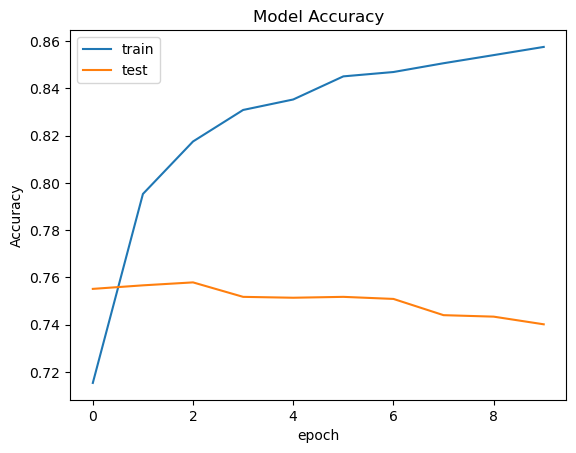

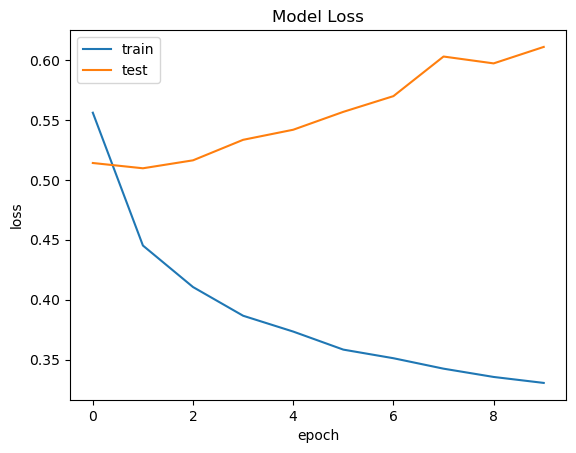

In [69]:
# model performance chart
import matplotlib.pyplot as plt

plt.plot(neural_net_history.history['acc'])
plt.plot(neural_net_history.history['val_acc'])

plt.title('Model Accuracy')
plt.ylabel("Accuracy")
plt.xlabel("epoch")
plt.legend(['train','test'],loc='upper left')
plt.show()


plt.plot(neural_net_history.history['loss'])
plt.plot(neural_net_history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel("loss")
plt.xlabel("epoch")
plt.legend(['train','test'],loc='upper left')
plt.show()

*italicized text*

### Convolution Neural Network

In [70]:
from keras.layers import Conv1D

In [71]:
# neural net architecture
cnn = Sequential()

embedding_layer=  Embedding(uniq_len,100,weights =[emb_matrix], input_length= max_pad , trainable = False)
cnn.add(embedding_layer)  #adding embd layer to model

cnn.add(Conv1D(128,5,activation='relu'))
cnn.add(GlobalMaxPooling1D())
cnn.add(Dense(1,activation='sigmoid'))



C:\Users\91776\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [72]:
# Model compiling

cnn.compile(optimizer='adam',loss='binary_crossentropy',metrics=['acc'])
cnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │     9,057,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,057,800 (34.55 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 9,057,800 (34.55 MB)

In [73]:
cnn_history = cnn.fit(X_train,Y_train , batch_size=128, epochs=10 ,verbose = 1,validation_split= 0.2)

Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 27s 84ms/step - acc: 0.7319 - loss: 0.5335 - val_acc: 0.8294 - val_loss: 0.3820
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 20s 79ms/step - acc: 0.8570 - loss: 0.3357 - val_acc: 0.8449 - val_loss: 0.3587
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 24s 94ms/step - acc: 0.8914 - loss: 0.2751 - val_acc: 0.8436 - val_loss: 0.3585
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 20s 79ms/step - acc: 0.9197 - loss: 0.2268 - val_acc: 0.8484 - val_loss: 0.3475
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 20s 79ms/step - acc: 0.9404 - loss: 0.1895 - val_acc: 0.8461 - val_loss: 0.3514
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 20s 79ms/step - acc: 0.9588 - loss: 0.1529 - val_acc: 0.8490 - val_loss: 0.3562
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 20s 78ms/step - acc: 0.9716 - loss: 0.1235 - val_acc: 0.8420 - val_loss: 0.3783
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 20s 79ms/step - acc: 0.9848 - loss: 0.0970 - val_acc: 0.8487 - val_loss: 0.3716
Epoch 9/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 

In [74]:
score = cnn.evaluate(X_test,Y_test,verbose=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - acc: 0.8557 - loss: 0.3782


In [75]:
# model performance
print(f'Test Score: {score[0]}')
print(f'Test Accuracy: {score[1]*100}')

Test Score: 0.3879851698875427
Test Accuracy: 84.96000170707703


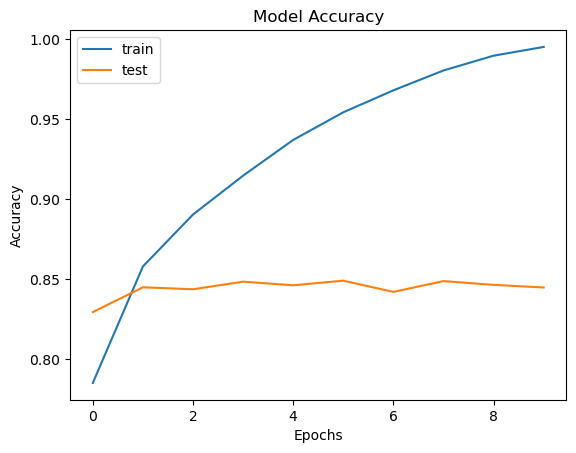

In [76]:
# model Performance plots

plt.plot(cnn_history.history['acc'])
plt.plot(cnn_history.history['val_acc'])
# plt.plot(cnn_history.history['val_loss'])
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['train','test'], loc = 'upper left')
plt.show()

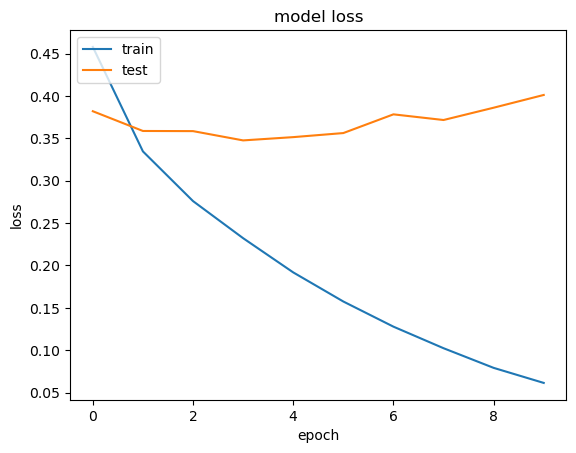

In [77]:
plt.plot(cnn_history.history['loss'])
plt.plot(cnn_history.history['val_loss'])

plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train','test'], loc = 'upper left')
plt.show()

### Recurrent Neural Network (Lstm)

In [78]:
from keras.layers import LSTM


In [79]:
lstm_model =  Sequential()

embd_layer  = Embedding(uniq_len,100,weights = [emb_matrix],input_length=max_pad,trainable=False)
lstm_model.add(embd_layer)
lstm_model.add(LSTM(128))

lstm_model.add(Dense(1,activation='sigmoid'))


In [80]:
# Model Compiling
lstm_model.compile(optimizer='adam',loss = 'binary_crossentropy',metrics=['acc'])
lstm_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │     9,057,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,057,800 (34.55 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 9,057,800 (34.55 MB)

In [82]:
lstm_model_history = lstm_model.fit(X_train,Y_train,batch_size = 128, epochs=6,verbose=1,validation_split=0.2)

Epoch 1/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 133s 506ms/step - acc: 0.6954 - loss: 0.5642 - val_acc: 0.7951 - val_loss: 0.4471
Epoch 2/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 112s 447ms/step - acc: 0.8152 - loss: 0.4230 - val_acc: 0.8301 - val_loss: 0.3948
Epoch 3/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 42s 166ms/step - acc: 0.8368 - loss: 0.3786 - val_acc: 0.8311 - val_loss: 0.3714
Epoch 4/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 43s 172ms/step - acc: 0.8532 - loss: 0.3449 - val_acc: 0.8503 - val_loss: 0.3430
Epoch 5/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 49s 196ms/step - acc: 0.8677 - loss: 0.3187 - val_acc: 0.8431 - val_loss: 0.3686
Epoch 6/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 77s 176ms/step - acc: 0.8744 - loss: 0.3034 - val_acc: 0.8160 - val_loss: 0.3927


In [97]:
score= lstm_model.evaluate(X_test,Y_test,verbose = 1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - acc: 0.8212 - loss: 0.3787


In [98]:
# Model Performance
print(f'Test Score : {score[0]}')
print(f'Test Accuracy: {score[1]}')

Test Score : 0.38213253021240234
Test Accuracy: 0.8177000284194946


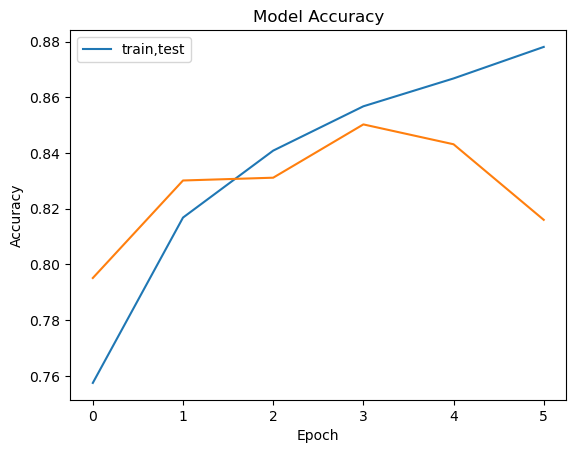

In [99]:
# model performance charts

plt.plot(lstm_model_history.history['acc'])
plt.plot(lstm_model_history.history['val_acc'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['train,test'],loc = 'upper left')
plt.show()

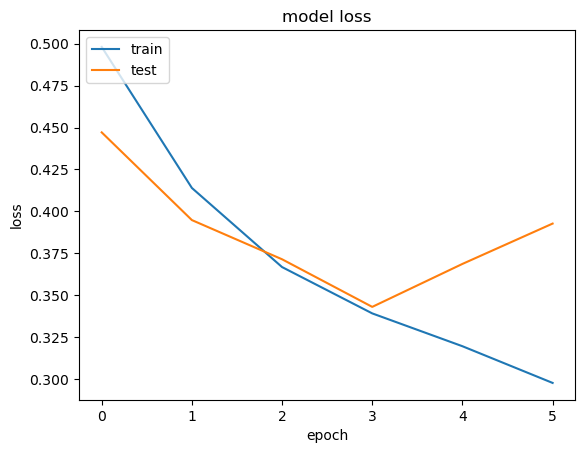

In [100]:
# model loss
plt.plot(lstm_model_history.history['loss'])
plt.plot(lstm_model_history.history['val_loss'])

plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train','test'], loc='upper left')
plt.show()

In [105]:
lstm_model.save(f'./lstm_model_acc{round(score[1],3)}.keras')

## Making predictions on Unseen Dataset

In [107]:
pwd

'C:\\Users\\91776\\OneDrive\\Desktop\\Sentiment_Analysis-main'

In [111]:
from tensorflow.keras.models import load_model
model = load_model('lstm_model_acc0.818.keras')
# pretrained_model = load_model(model_path)

C:\Users\91776\anaconda3\Lib\site-packages\keras\src\saving\saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 7 variables whereas the saved optimizer has 12 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [113]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (128, 100, 100)        │     9,057,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (128, 128)             │       117,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (128, 1)               │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,292,556 (35.45 MB)

 Trainable params: 117,377 (458.50 KB)

 Non-trainable params: 9,057,800 (34.55 MB)

 Optimizer params: 117,379 (458.52 KB)

In [119]:
review = pd.read_csv('a3_IMDb_Unseen_Reviews.csv')

In [121]:
review.head()

,Unnamed: 0,Movie,Review Text,IMDb Rating
0,0,Ex Machina,Intelligent Movie.\nThis movie is obviously al...,9
1,1,Ex Machina,Extraordinary and thought-provoking.\n'Ex mach...,10
2,2,Ex Machina,"Poor story, only reasonable otherwise.\nIf I h...",3
3,3,Ex Machina,Had Great Potential.\nThis movie is one of the...,1
4,4,Eternals,Amazing visuals and philosophical concepts!\n\...,10


In [123]:
review['Review Text'][2]

"Poor story, only reasonable otherwise.\nIf I had realised this was by Alex Garland I would not have bothered watching. I remember reading his book the Beach years ago and thinking 'there's something not very nice about this'. At the time I wasn't sure what it was. But now having seen Ex Machina, I have the same feeling. That the story has been chosen simply to appeal to a large audience, in a rather manipulative, unthinking and unfeeling way.\n\nI don't normally write bad reviews - of anything. Preferring to focus on the positive. But I so dislike this I felt I had to write something to put people off wasting their time, or assimilating some of this 'nastiness'.\n\nIn the case of Ex Machina I can just imagine Garland wondering what he would do for his next project, googling AI and quickly finding the AI Box Experiment. And rather than do the heart- and soul-searching work that would be necessary to produce anything original I imagine him quickly turning somebody else's idea into his n

In [125]:

text_reviews = list(review['Review Text'])

unseen_processed = []

for reviews in text_reviews:
  unseen_processed.append(preprocess(reviews))


# unseen_processed = []

# text = list(movie_review['review'])

# for tex in text:
#   X.append(preprocess(tex))

In [127]:
unseen_processed


['intelligent movie movie obviously allegorical fascinating tale ai mainly manipulation power wanting action spectacular cgi movie aimed people like think rather passively wait entertained themes ai also surveillance excellent points data us collected phone companies search engine companies commercial operating systems makers plot seems simple extremely clever protagonist playing games trying stay one step ahead one another movie perfectly consistent internal logic plays perfectly go expecting much however see people satisfied movie sets brilliantly therefore give least recent movies getting movie succeeds another recent movie ai transcendence think called failed interesting failure third movie ai spanish movie called eva also brilliant eva moving movie philosophical movies perfect different ways ai name movie ava seems nod title spanish movie aside nice stars appeared ex machina eva casting great course several aspects movie unrealistic often absurd allegorical movie acceptable movie 

In [129]:
# tokenization of text
unseen_token = tokens.texts_to_sequences(unseen_processed)

# pooling instance to have max len of 100 tokens

unseen_padded = pad_sequences(unseen_token,padding = 'post',maxlen= max_pad)


In [131]:
# passing tokens to lstm model best performed among 3
unseen_sentiment = lstm_model.predict(unseen_padded)
unseen_sentiment

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 901ms/step


array([[0.6830342 ],
       [0.9908785 ],
       [0.18916385],
       [0.23982355],
       [0.92907125],
       [0.02713892]], dtype=float32)

In [133]:
review.head(2)

,Unnamed: 0,Movie,Review Text,IMDb Rating
0,0,Ex Machina,Intelligent Movie.\nThis movie is obviously al...,9
1,1,Ex Machina,Extraordinary and thought-provoking.\n'Ex mach...,10


In [135]:
# saving  output on google drive in form of dataframe

review['Predicted Sentiments'] = np.round(unseen_sentiment*10,1) #multiplied by 10 for range(0-10)

df_prediction_sentiments = pd.DataFrame(review['Predicted Sentiments'], columns = ['Predicted Sentiments'])
df_Movie = pd.DataFrame(review['Movie'],columns = ['Movie'])
df_review_text = pd.DataFrame(review['Review Text'],columns = ['Review Text'])
df_imdb_ratings = pd.DataFrame(review['IMDb Rating'],columns = ['IMDb Rating'])


df = pd.concat([df_Movie,df_review_text,df_imdb_ratings,df_prediction_sentiments],axis =1)
df.to_csv('./unseen_Predictions.csv',sep = ',',encoding='UTF-8')
df.head(5)

,Movie,Review Text,IMDb Rating,Predicted Sentiments
0,Ex Machina,Intelligent Movie.\nThis movie is obviously al...,9,6.8
1,Ex Machina,Extraordinary and thought-provoking.\n'Ex mach...,10,9.9
2,Ex Machina,"Poor story, only reasonable otherwise.\nIf I h...",3,1.9
3,Ex Machina,Had Great Potential.\nThis movie is one of the...,1,2.4
4,Eternals,Amazing visuals and philosophical concepts!\n\...,10,9.3


In [137]:
# saving model as a pickel file
import pickle
pickle.dump(lstm_model,open('model.pkl','wb'))